# Assignment 5 - Datascience

# Mohammad Hossein Basouli

In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

data_science_5_sbu_path = kagglehub.competition_download('data-science-5-sbu')

print('Data source import complete.')


100%|██████████| 48.2M/48.2M [00:03<00:00, 16.4MB/s]

Extracting files...


Data source import complete.


# Imports

In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [6]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.0 MB/s eta 0:00:00


In [7]:
# Standard library imports
import os
import time

# Third-party core utilities
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import shap

# Plotting configuration (side-effect)
plt.style.use('ggplot')
pd.set_option('display.max_columns', 35)

# Encoders
from category_encoders import TargetEncoder

# Models - Tree-based
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Models - Other regressors
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures

# Gaussian process kernels
from sklearn.gaussian_process.kernels import Matern, RBF, RationalQuadratic

# Model selection and evaluation
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_log_error, make_scorer
from sklearn.inspection import permutation_importance

# Pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Dataset Orientation

In [8]:
df = pd.read_csv('/root/.cache/kagglehub/competitions/data-science-5-sbu/train.csv')

In [9]:
df.shape

(1100000, 21)

In [10]:
df.describe()

,ID,Years Lived,Yearly Earnings,Dependent Count,Wellness Index,Prior Claims,Automobile Age,Financial Rating,Coverage Period,Policy Cost
count,1.100000e+06,1.082781e+06,1.058849e+06,999297.000000,1.031954e+06,766140.000000,1.099994e+06,973595.000000,1.099999e+06,1.100000e+06
mean,5.499995e+05,4.114396e+01,3.273969e+04,2.009234,2.561357e+01,1.003279,9.573080e+00,593.003554,5.016976e+00,1.102681e+03
std,3.175428e+05,1.353912e+01,3.218211e+04,1.417255,1.220411e+01,0.983413,5.776708e+00,149.951723,2.594547e+00,8.650824e+02
min,0.000000e+00,1.800000e+01,1.000000e+00,0.000000,2.012237e+00,0.000000,0.000000e+00,300.000000,1.000000e+00,2.000000e+01
25%,2.749998e+05,3.000000e+01,7.991000e+03,1.000000,1.591814e+01,0.000000,5.000000e+00,468.000000,3.000000e+00,5.140000e+02
50%,5.499995e+05,4.100000e+01,2.389700e+04,2.000000,2.458200e+01,1.000000,1.000000e+01,595.000000,5.000000e+00,8.720000e+02
75%,8.249992e+05,5.300000e+01,4.463300e+04,3.000000,3.452768e+01,2.000000,1.500000e+01,721.000000,7.000000e+00,1.509000e+03
max,1.099999e+06,6.400000e+01,1.499970e+05,4.000000,5.897591e+01,9.000000,1.900000e+01,849.000000,9.000000e+00,4.999000e+03


In [11]:
df.head()

,ID,Years Lived,Sex,Yearly Earnings,Relationship Status,Dependent Count,Academic Standing,Job Title,Wellness Index,Region,Coverage Class,Prior Claims,Automobile Age,Financial Rating,Coverage Period,Coverage Commencement,Client Review,Tobacco Use,Physical Activity,Asset Category,Policy Cost
0,0,26.0,Man,8071.0,Unmarried,NaN,Secondary,NaN,17.927378,City,Standard,0.0,4.0,622.0,2.0,2024-06-10 15:21:39.261856,NaN,Smoker,Everyday,Residence,533.0
1,1,42.0,Man,49.0,Unmarried,2.0,Undergraduate,Jobless,49.828507,City,Standard,1.0,15.0,568.0,6.0,2023-01-06 15:21:39.272456,Moderate,Smoker,Once a Week,Unit,4795.0
2,2,52.0,Man,80793.0,Spouse,2.0,Doctorate,Jobless,27.539608,Exurban,Full,2.0,2.0,467.0,7.0,2021-03-18 15:21:39.237118,Satisfactory,Non-Smoker,Seldom,Residence,151.0
3,3,33.0,Man,30663.0,Unmarried,1.0,Undergraduate,Freelancer,24.355045,Countryside,Standard,1.0,10.0,710.0,2.0,2023-08-28 15:21:39.102694,Unsatisfactory,Non-Smoker,Seldom,Residence,588.0
4,4,34.0,Man,59638.0,Spouse,0.0,Undergraduate,NaN,33.394840,Countryside,Superior,1.0,10.0,431.0,2.0,2024-03-17 15:21:39.171102,Unsatisfactory,Smoker,Once a Month,Residence,662.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1100000 non-null  int64  
 1   Years Lived            1082781 non-null  float64
 2   Sex                    1100000 non-null  object 
 3   Yearly Earnings        1058849 non-null  float64
 4   Relationship Status    1083018 non-null  object 
 5   Dependent Count        999297 non-null   float64
 6   Academic Standing      1100000 non-null  object 
 7   Job Title              771458 non-null   object 
 8   Wellness Index         1031954 non-null  float64
 9   Region                 1100000 non-null  object 
 10  Coverage Class         1100000 non-null  object 
 11  Prior Claims           766140 non-null   float64
 12  Automobile Age         1099994 non-null  float64
 13  Financial Rating       973595 non-null   float64
 14  Coverage Period   

# Exploratory Data Analysis

## Inspection of Unique Values:

In [13]:
cat_features = df.select_dtypes(include=['object'])

for cat in cat_features:
    print('------------------------')
    print(f'Unique Values for {cat}:')
    print(df[cat].value_counts())

------------------------
Unique Values for Sex:
Sex
Man      552140
Woman    547860
Name: count, dtype: int64
------------------------
Unique Values for Relationship Status:
Relationship Status
Unmarried    362319
Spouse       361449
Separated    359250
Name: count, dtype: int64
------------------------
Unique Values for Academic Standing:
Academic Standing
Graduate         278404
Doctorate        278197
Undergraduate    278078
Secondary        265321
Name: count, dtype: int64
------------------------
Unique Values for Job Title:
Job Title
Working       259004
Freelancer    258875
Jobless       253579
Name: count, dtype: int64
------------------------
Unique Values for Region:
Region
Exurban        368244
Countryside    367534
City           364222
Name: count, dtype: int64
------------------------
Unique Values for Coverage Class:
Coverage Class
Superior    368353
Full        366267
Standard    365380
Name: count, dtype: int64
------------------------
Unique Values for Coverage Commen

## Inspection of Missing Values:

In [14]:
df.isna().sum()

,0
ID,0
Years Lived,17219
Sex,0
Yearly Earnings,41151
Relationship Status,16982
Dependent Count,100703
Academic Standing,0
Job Title,328542
Wellness Index,68046
Region,0


## Univariate Analysis:

In [15]:
def plot_numerical_distributions(data):
    """
    Plot distributions of all numerical columns in a dataset using subplots.

    Parameters:
    data (pd.DataFrame): Input dataframe containing the data
    """
    # Select only numerical columns
    numerical_cols = data.select_dtypes(include=[np.number]).columns.drop(labels=['ID'])

    # Calculate number of rows needed (3 columns per row)
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    # Create figure and axes
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()  # Flatten in case of 2D array of axes

    # Plot each numerical column
    for i, col in enumerate(numerical_cols):
        if i < len(axes):  # Ensure we don't exceed the number of axes
            sns.histplot(data=data, x=col, kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')
            axes[i].set_xlabel('')

    # Hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

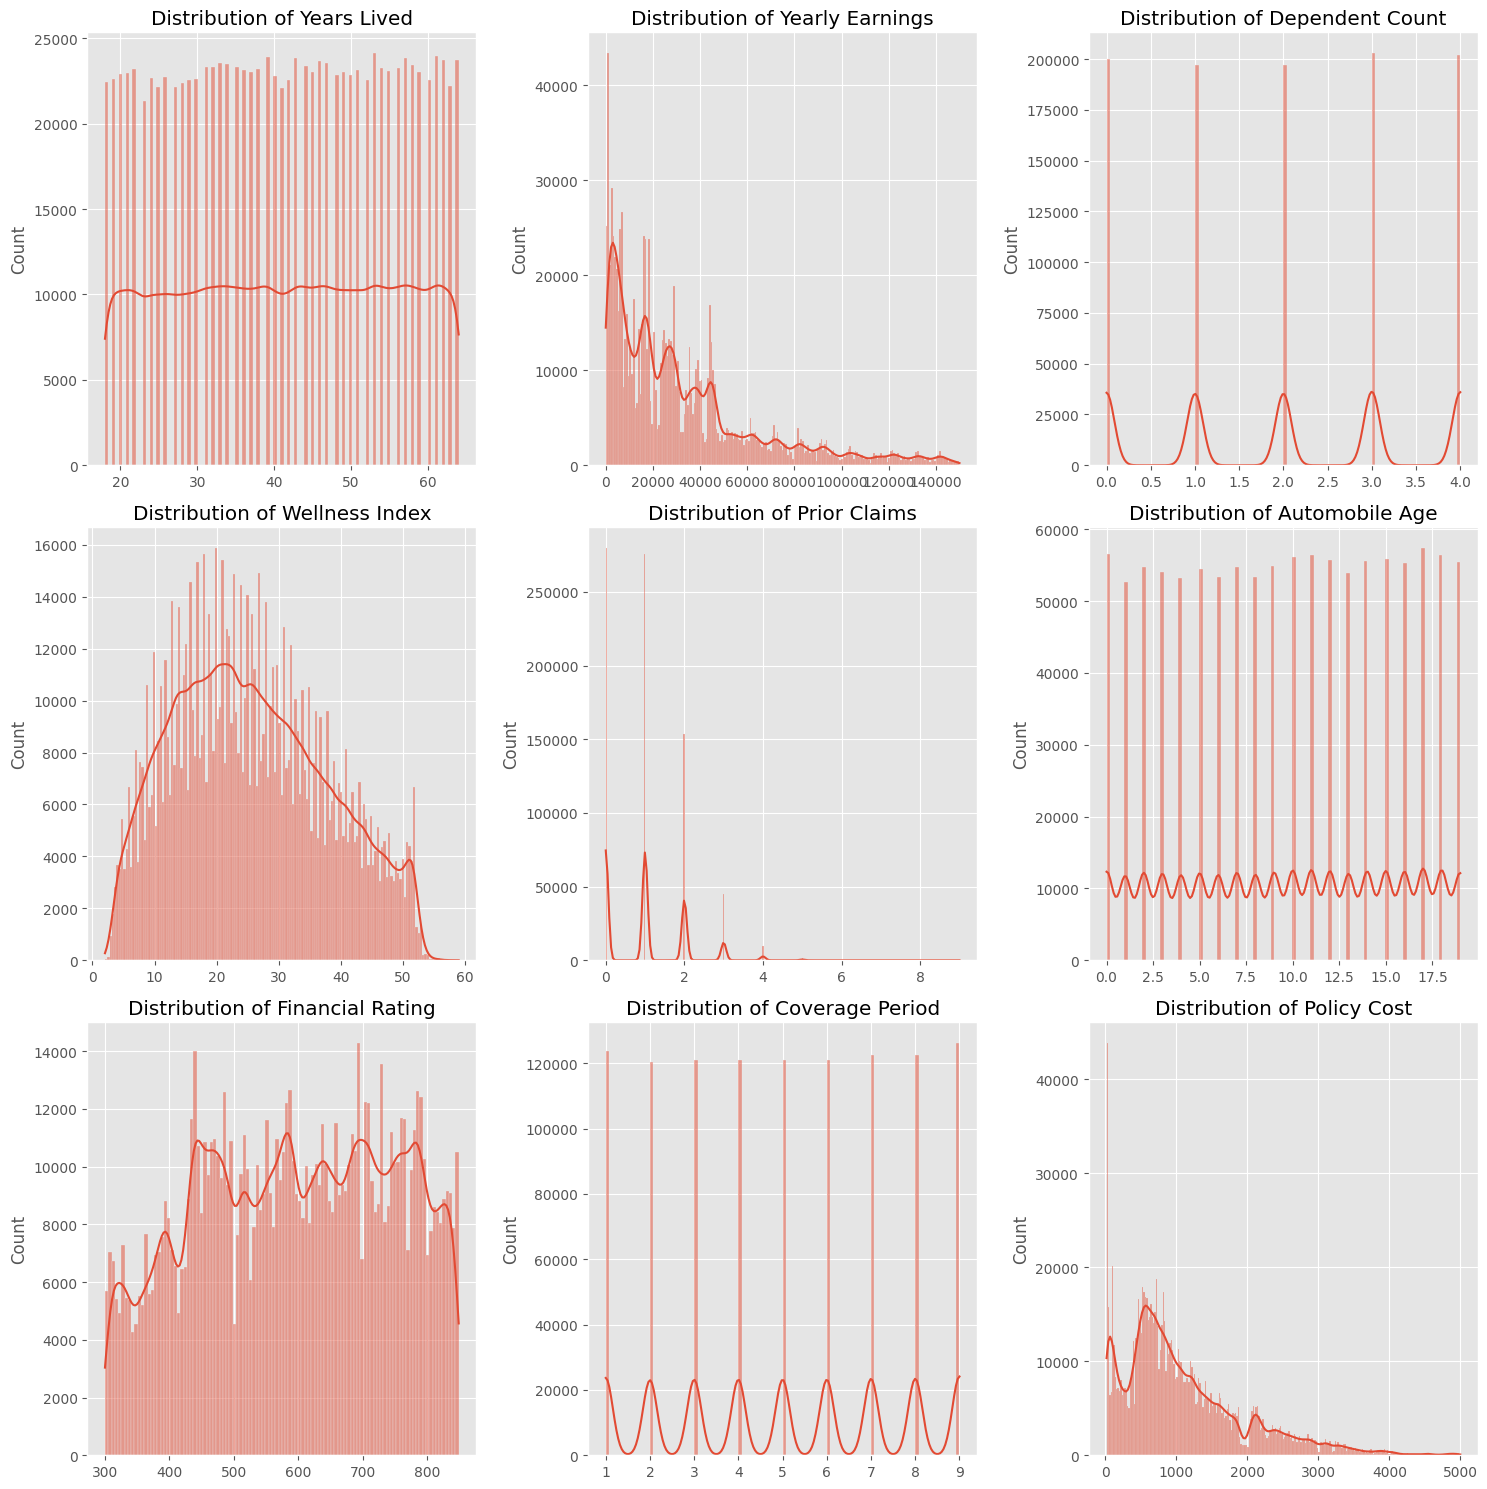

In [16]:
plot_numerical_distributions(df)

## Bivariate Analysis:

<Axes: >

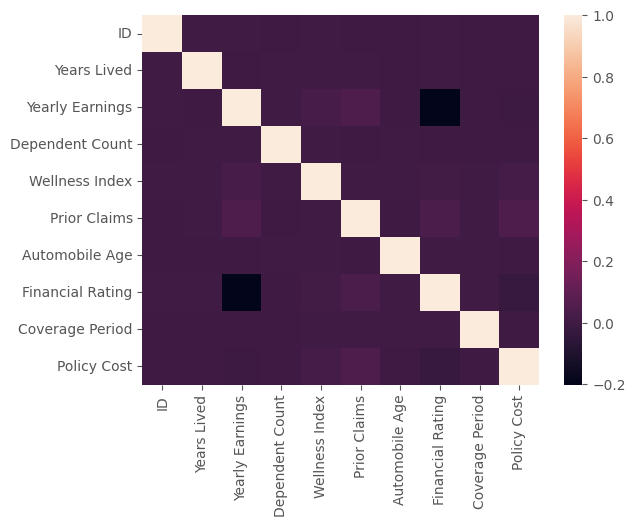

In [17]:
sns.heatmap(df.corr(method='pearson', numeric_only=True))

# Data Preprocessing

## Data Type Correction:

In [18]:
df['Years Lived'] = df['Years Lived'].astype('Int32')
df['Dependent Count'] = df['Dependent Count'].astype('Int32')
df['Prior Claims'] = df['Prior Claims'].astype('Int32')
df['Automobile Age'] = df['Automobile Age'].astype('Int32')
df['Coverage Period'] = df['Coverage Period'].astype('Int32')
df['Coverage Commencement'] = pd.to_datetime(df['Coverage Commencement'])

## Imputation of Missing Values:
- Datetime and Categorial -> Mode
- Numerics -> Median

In [19]:
def impute_missing_values(df):
    """
    Imputes NaN/NaT values in a DataFrame: median for numerical columns, mode for categorical and datetime columns.

    Parameters:
    df (pandas.DataFrame): Input DataFrame with potential NaN/NaT values

    Returns:
    pandas.DataFrame: DataFrame with imputed NaN/NaT values
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_imputed = df.copy()

    # Get numerical, categorical, and datetime columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    datetime_cols = df.select_dtypes(include=['datetime64[ns]']).columns

    # Impute numerical columns with median
    for col in numerical_cols:
        if df_imputed[col].isna().any():
            median_value = df_imputed[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_value)

    # Impute categorical columns with mode
    for col in categorical_cols:
        if df_imputed[col].isna().any():
            mode_value = df_imputed[col].mode()[0]  # Take the first mode
            df_imputed[col] = df_imputed[col].fillna(mode_value)

    # Impute datetime columns with mode
    for col in datetime_cols:
        if df_imputed[col].isna().any():
            mode_value = df_imputed[col].mode()[0]  # Take the first mode
            df_imputed[col] = df_imputed[col].fillna(mode_value)

    return df_imputed

In [20]:
df = impute_missing_values(df)
df.isna().sum()

,0
ID,0
Years Lived,0
Sex,0
Yearly Earnings,0
Relationship Status,0
Dependent Count,0
Academic Standing,0
Job Title,0
Wellness Index,0
Region,0


# Feature Engineering

## Feature Expansion:

In [21]:
# Extract temporal features with clear names
df['CoverageCommencement_Year'] = df['Coverage Commencement'].dt.year
df['CoverageCommencement_Month'] = df['Coverage Commencement'].dt.month
df['CoverageCommencement_DayOfWeek'] = df['Coverage Commencement'].dt.dayofweek
df['CoverageCommencement_DayOfYear'] = df['Coverage Commencement'].dt.dayofyear

# Define season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['CoverageCommencement_Season'] = df['Coverage Commencement'].dt.month.apply(get_season)

## Feature Transformation:
- $Yearly Earnings$ -> $\sqrt(Yearly Earnings)$


In [22]:
df['Yearly Earnings'] = df['Yearly Earnings'].apply(func=np.sqrt)

## Feature Encoding:
1. Label Encodings:
  - *Academic Standings*
  - *Coverage Class*
  - *Client Review*
  - *Physical Activity*

2. Target Encodings (with cross validation):
  - *Sex*
  - *Relationship Status*
  - *Job Title*
  - *Region*
  - *Tobacco Use*
  - *Asset Category*
  - *CoverageCommencement_DayOfWeek*
  - *CoverageCommencement_Season*

In [23]:
# **Label Encoding**
# Define mappings
academic_standing_map = {'Secondary': 0, 'Undergraduate': 1, 'Graduate': 2, 'Doctorate': 3}
coverage_class_map = {'Standard': 1, 'Full': 2, 'Superior': 3}
client_review_map = {'Unsatisfactory': -1, 'Moderate': 0, 'Satisfactory': 1}
physical_activity_map = {'Seldom': 0, 'Once a Month': 1, 'Once a Week': 2, 'Everyday': 4}

# Apply mappings
df['Academic Standing'] = df['Academic Standing'].map(academic_standing_map)
df['Coverage Class'] = df['Coverage Class'].map(coverage_class_map)
df['Client Review'] = df['Client Review'].map(client_review_map)
df['Physical Activity'] = df['Physical Activity'].map(physical_activity_map)

# **Target Encoding with Cross-Validation**
target_encode_cols = ['Sex', 'Relationship Status', 'Job Title', 'Region', 'Tobacco Use', 'Asset Category', 'CoverageCommencement_DayOfWeek', 'CoverageCommencement_Season']

# Initialize TargetEncoder with smoothing
encoder = TargetEncoder(cols=target_encode_cols, smoothing=1.0)

# Apply target encoding
df[target_encode_cols] = encoder.fit_transform(df[target_encode_cols], df['Policy Cost'])


# Model Training & Evaluation
Models:
1. **Random Forests**
2. **AdaBoost**
3. **XGBoost**
4. **Light Boost**
5. **Cat Boost**
6. **Polynomial Regression with Ridge Regularization**

## Definition of the Metric:

In [24]:
# Define RMSLE function and scorer
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)  # Ensure predictions are non-negative
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

## Splitting:

In [25]:
X, y = df.drop(columns=['ID', 'Policy Cost', 'Coverage Commencement']), df['Policy Cost']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Hyperparameter Tuning: (subsampling of size 0.01)

In [26]:
def tune_and_save_models(X_train, y_train, model_dir='saved_models', tune_frac=1.0):
    os.makedirs(model_dir, exist_ok=True)

    # Subsample for faster tuning if tune_frac < 1.0
    if tune_frac < 1.0:
        X_train, _, y_train, _ = train_test_split(
            X_train, y_train, train_size=tune_frac, random_state=42, stratify=None
        )

    param_grids = {
        'RF': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100],
                'max_depth': [10, 15],
                'min_samples_leaf': [2, 5],
                'min_samples_split': [4, 8],
                'max_features': ['sqrt', 'log2'],
                'bootstrap': [True],
                'n_jobs': [-1]
            }
        },
        'AdaBoost': {
            'model': AdaBoostRegressor(random_state=42),
            'params': {
                'n_estimators': [50, 100],
                'learning_rate': [0.1, 0.5, 1.0]
            }
        },
        'XGBoost': {
            'model': XGBRegressor(eval_metric='rmse', random_state=42, verbosity=0),
            'params': {
                'n_estimators': [50, 100],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5],
                'subsample': [0.8, 1]
            }
        },
        'LightGBM': {
            'model': LGBMRegressor(random_state=42, verbose=-1),
            'params': {
                'n_estimators': [100],
                'learning_rate': [0.05, 0.1],
                'max_depth': [8, 10],
                'min_child_samples': [5, 10],
                'subsample': [0.8, 1],
                'colsample_bytree': [0.8, 1]
            }
        },
        'CatBoost': {
            'model': CatBoostRegressor(verbose=0, random_state=42),
            'params': {
                'iterations': [100, 200],
                'learning_rate': [0.01, 0.05],
                'depth': [4, 6]
            }
        },
        'PolynomialRidge': {
            'model': Pipeline([
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('reg', Ridge())
            ]),
            'params': {
                'poly__degree': [2, 3],
                'reg__alpha': [0.1, 1.0, 10.0],  # L2 penalty strength
                'reg__fit_intercept': [True, False]
            }
        },
        # 'PolynomialLasso': {
        #     'model': Pipeline([
        #         ('scaler', StandardScaler()),
        #         ('poly', PolynomialFeatures(include_bias=False)),
        #         ('reg', Lasso(max_iter=10000))  # Increase max_iter for convergence
        #     ]),
        #     'params': {
        #         'poly__degree': [2, 3],
        #         'reg__alpha': [0.001, 0.01, 0.1],  # L1 penalty strength
        #         'reg__fit_intercept': [True, False]
        #     }
        # },
        # 'KNN': {
        #     'model': Pipeline([
        #         ('scaler', StandardScaler()),
        #         ('reg', KNeighborsRegressor())
        #     ]),
        #     'params': {
        #         'reg__n_neighbors': [3, 5, 7],
        #         'reg__weights': ['uniform', 'distance'],
        #         'reg__p': [1, 2]
        #     }
        # },
        # 'SVR': {
        #     'model': Pipeline([
        #         ('scaler', StandardScaler()),
        #         ('reg', SVR())
        #     ]),
        #     'params': {
        #         'reg__kernel': ['rbf', 'linear'],
        #         'reg__C': [0.1, 1, 10],
        #         'reg__epsilon': [0.01, 0.1, 0.5]
        #     }
        # }
        # 'GPR': {
        #     'model': Pipeline([
        #         ('scaler', StandardScaler()),
        #         ('reg', GaussianProcessRegressor(random_state=42))
        #     ]),
        #     'params': {
        #         'reg__kernel': [RBF(), Matern(), RationalQuadratic()],
        #         'reg__alpha': [1e-10, 1e-5, 1e-2]
        #     }
        # }
    }

    for name, cfg in param_grids.items():
        print(f"\n🔍 Tuning {name}...")
        start_time = time.time()

        grid = GridSearchCV(
            cfg['model'], cfg['params'], cv=3,
            scoring=rmsle_scorer, n_jobs=-1, return_train_score=True
        )
        grid.fit(X_train, y_train)
        duration = time.time() - start_time

        best_model = grid.best_estimator_
        best_score = grid.best_score_
        best_index = grid.best_index_
        std_test = grid.cv_results_['std_test_score'][best_index]
        mean_train_score = grid.cv_results_['mean_train_score'][best_index]
        std_train = grid.cv_results_['std_train_score'][best_index]

        print(f"✅ Best RMSLE (Validation): {best_score:.4f} ± {std_test:.4f}")
        print(f"🧪 Best RMSLE (Train): {mean_train_score:.4f} ± {std_train:.4f}")
        print(f"⚙️  Best Parameters: {grid.best_params_}")
        print(f"⏱️  Time taken: {duration:.2f} seconds")

        model_path = os.path.join(model_dir, f"{name}_best_model.pkl")
        joblib.dump(best_model, model_path)
        print(f"💾 Saved {name} best model to: {model_path}")


In [27]:
tune_and_save_models(X_train, y_train, model_dir='saved_models', tune_frac=0.01)


🔍 Tuning RF...
✅ Best RMSLE (Validation): -1.1604 ± 0.0184
🧪 Best RMSLE (Train): -1.0690 ± 0.0122
⚙️  Best Parameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 50, 'n_jobs': -1}
⏱️  Time taken: 71.23 seconds
💾 Saved RF best model to: saved_models/RF_best_model.pkl

🔍 Tuning AdaBoost...
✅ Best RMSLE (Validation): -1.2231 ± 0.0171
🧪 Best RMSLE (Train): -1.2195 ± 0.0123
⚙️  Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
⏱️  Time taken: 12.73 seconds
💾 Saved AdaBoost best model to: saved_models/AdaBoost_best_model.pkl

🔍 Tuning XGBoost...
✅ Best RMSLE (Validation): -1.1566 ± 0.0178
🧪 Best RMSLE (Train): -1.0877 ± 0.0139
⚙️  Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
⏱️  Time taken: 7.34 seconds
💾 Saved XGBoost best model to: saved_models/XGBoost_best_model.pkl

🔍 Tuning LightGBM...
✅ Best RMSLE (Validation): -1.1551 ± 0.0151
🧪 Best RMSLE (Train

## Re-training & Evaluation: (subsampling of size 0.05)

In [28]:
def evaluate_models(X_train, y_train, X_val, y_val, model_dir='saved_models', subsample_fraction=0.01):
    # Subsample train and validation sets
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train, y_train, train_size=subsample_fraction, random_state=42
    )
    X_val_sub, _, y_val_sub, _ = train_test_split(
        X_val, y_val, train_size=subsample_fraction, random_state=42
    )

    val_results = {}
    train_results = {}
    trained_models = {}

    model_files = [f for f in os.listdir(model_dir) if f.endswith('_best_model.pkl')]
    for file in model_files:
        name = file.split('_best_model.pkl')[0]
        model_path = os.path.join(model_dir, file)
        model = joblib.load(model_path)

        print(f"\n🔁 Retraining and evaluating {name}...")
        model.fit(X_train_sub, y_train_sub)
        trained_models[name] = model

        # Predictions
        y_train_pred = model.predict(X_train_sub)
        y_val_pred = model.predict(X_val_sub)

        # Compute RMSLE
        train_rmsle = rmsle(y_train_sub, y_train_pred)
        val_rmsle = rmsle(y_val_sub, y_val_pred)

        train_results[name] = train_rmsle
        val_results[name] = val_rmsle

        print(f"{name} - Training RMSLE: {train_rmsle:.4f}")
        print(f"{name} - Validation RMSLE: {val_rmsle:.4f}")

    # Summary
    print("\n📊 Summary of RMSLE Scores:")
    print(f"{'Model':<12} {'Train RMSLE':>12} {'Validation RMSLE':>18}")
    print("-" * 42)
    for name in sorted(val_results.keys()):
        print(f"{name:<12} {train_results[name]:>12.4f} {val_results[name]:>18.4f}")

    return trained_models

In [29]:
trained_models = evaluate_models(X_train, y_train, X_val, y_val, model_dir='saved_models', subsample_fraction=0.05)


🔁 Retraining and evaluating CatBoost...
CatBoost - Training RMSLE: 1.1518
CatBoost - Validation RMSLE: 1.1499

🔁 Retraining and evaluating XGBoost...
XGBoost - Training RMSLE: 1.1459
XGBoost - Validation RMSLE: 1.1485

🔁 Retraining and evaluating PolynomialRidge...
PolynomialRidge - Training RMSLE: 1.1636
PolynomialRidge - Validation RMSLE: 1.1561

🔁 Retraining and evaluating RF...
RF - Training RMSLE: 1.1365
RF - Validation RMSLE: 1.1543

🔁 Retraining and evaluating LightGBM...
LightGBM - Training RMSLE: 1.1385
LightGBM - Validation RMSLE: 1.1416

🔁 Retraining and evaluating AdaBoost...
AdaBoost - Training RMSLE: 1.2418
AdaBoost - Validation RMSLE: 1.2315

📊 Summary of RMSLE Scores:
Model         Train RMSLE   Validation RMSLE
------------------------------------------
AdaBoost           1.2418             1.2315
CatBoost           1.1518             1.1499
LightGBM           1.1385             1.1416
PolynomialRidge       1.1636             1.1561
RF                 1.1365          

## Feature Importances: (subsampling of size 0.01)

In [30]:
def evaluate_feature_importance(models, X_val, y_val,
                                subsample_fraction=1.0,
                                top_k=10,
                                random_state=42):
    """
    Compute and print feature importances for each model using the most efficient method:
      - impurity for tree-based models
      - |coef_| for linear models
      - permutation importance for others

    Parameters
    ----------
    models : dict[str, estimator]
        Dictionary of fitted models with names as keys.
    X_val : pd.DataFrame
        Validation features.
    y_val : array-like
        Validation targets.
    subsample_fraction : float, default=1.0
        Fraction of validation data to use (via train_test_split).
    top_k : int, default=10
        Number of top features to display for each model.
    random_state : int, default=42
        Random seed for splitting and permutation.

    Returns
    -------
    pd.DataFrame
        DataFrame of feature importances: index = model names, columns = feature names.
    """
    # Subsample validation data
    if subsample_fraction < 1.0:
        X_sub, _, y_sub, _ = train_test_split(
            X_val, y_val,
            train_size=subsample_fraction,
            random_state=random_state,
            shuffle=True
        )
    else:
        X_sub, y_sub = X_val, y_val

    fi_dict = {}

    print("\n📊 Feature Importances per Model:")
    print("-" * 50)

    for name, model in models.items():
        # Determine importance method
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
            method = "Impurity-based"
        elif hasattr(model, "coef_"):
            coef = model.coef_
            imp = np.abs(coef.ravel() if coef.ndim > 1 else coef)
            method = "Coefficient-based"
        else:
            pi = permutation_importance(
                model, X_sub, y_sub,
                n_repeats=5,
                random_state=random_state,
                n_jobs=-1
            )
            imp = pi.importances_mean
            method = "Permutation-based"

        # Store and print top-k
        fi_dict[name] = imp
        sorted_idx = np.argsort(imp)[::-1]
        top_features = X_val.columns[sorted_idx[:top_k]]
        top_scores = imp[sorted_idx[:top_k]]

        print(f"\n🔍 Model: {name} ({method})")
        for feat, score in zip(top_features, top_scores):
            print(f"  {feat:30s} -> {score:.4f}")

    # Create DataFrame for return
    fi_df = pd.DataFrame.from_dict(
        fi_dict,
        orient="index",
        columns=X_val.columns
    )
    return fi_df


In [31]:
importances = evaluate_feature_importance(trained_models, X_val, y_val, subsample_fraction=0.01)


📊 Feature Importances per Model:
--------------------------------------------------

🔍 Model: CatBoost (Impurity-based)
  Yearly Earnings                -> 23.3703
  Financial Rating               -> 13.9649
  Prior Claims                   -> 12.2697
  Wellness Index                 -> 7.4267
  CoverageCommencement_Year      -> 7.3464
  Automobile Age                 -> 3.1645
  CoverageCommencement_DayOfWeek -> 2.7919
  Years Lived                    -> 2.6373
  Client Review                  -> 2.5793
  Physical Activity              -> 2.2474

🔍 Model: XGBoost (Impurity-based)
  CoverageCommencement_Year      -> 0.1165
  Prior Claims                   -> 0.0833
  Yearly Earnings                -> 0.0640
  Financial Rating               -> 0.0623
  Wellness Index                 -> 0.0484
  Physical Activity              -> 0.0450
  Client Review                  -> 0.0435
  CoverageCommencement_DayOfWeek -> 0.0395
  Coverage Period                -> 0.0389
  CoverageCommencement_D

# Prediction

## Test Set & Sample Set Loading

In [32]:
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/data-science-5-sbu/x_test.csv')
sample_df = pd.read_csv('/root/.cache/kagglehub/competitions/data-science-5-sbu/sample_submission.csv')

## Data Preprocessing

### Data Type Correction:

In [33]:
test_df['Years Lived'] = test_df['Years Lived'].astype('Int32')
test_df['Dependent Count'] = test_df['Dependent Count'].astype('Int32')
test_df['Prior Claims'] = test_df['Prior Claims'].astype('Int32')
test_df['Automobile Age'] = test_df['Automobile Age'].astype('Int32')
test_df['Coverage Period'] = test_df['Coverage Period'].astype('Int32')
test_df['Coverage Commencement'] = pd.to_datetime(test_df['Coverage Commencement'])

### Imputation of Missing Values:

In [34]:
test_df = impute_missing_values(test_df)

## Feature Engineering

### Feature Expansion:

In [35]:
# Extract temporal features with clear names
test_df['CoverageCommencement_Year'] = test_df['Coverage Commencement'].dt.year
test_df['CoverageCommencement_Month'] = test_df['Coverage Commencement'].dt.month
test_df['CoverageCommencement_DayOfWeek'] = test_df['Coverage Commencement'].dt.dayofweek
test_df['CoverageCommencement_DayOfYear'] = test_df['Coverage Commencement'].dt.dayofyear

# Define season mapping
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

test_df['CoverageCommencement_Season'] = test_df['Coverage Commencement'].dt.month.apply(get_season)

### Feature Encoding:

In [36]:
# Apply mappings
test_df['Academic Standing'] = test_df['Academic Standing'].map(academic_standing_map)
test_df['Coverage Class'] = test_df['Coverage Class'].map(coverage_class_map)
test_df['Client Review'] = test_df['Client Review'].map(client_review_map)
test_df['Physical Activity'] = test_df['Physical Activity'].map(physical_activity_map)

# Apply the same encoding to test data
test_df[target_encode_cols] = encoder.transform(test_df[target_encode_cols])

## Prediction:

In [37]:
X_test = test_df.drop(columns=['ID', 'Coverage Commencement'])

In [38]:
def predict_and_save(models_dict: dict, X_test, sample_df, output_dir='predictions'):
    os.makedirs(output_dir, exist_ok=True)

    # Extract IDs
    ids = sample_df['ID']

    predictions = []

    # Individual model predictions
    for model_name, model in models_dict.items():
        print(f"📤 Predicting with {model_name}...")

        # Predict
        y_pred = model.predict(X_test)
        predictions.append(y_pred)

        # Create prediction DataFrame
        prediction_df = pd.DataFrame({
            'ID': ids,
            'Policy Cost': y_pred
        })

        # Save to CSV
        output_path = os.path.join(output_dir, f"{model_name}_predictions.csv")
        prediction_df.to_csv(output_path, index=False)
        print(f"✅ Saved predictions to: {output_path}")

    # Compute average prediction for ensemble
    if predictions:
        print("🧠 Computing ensemble prediction by averaging...")
        ensemble_pred = np.mean(predictions, axis=0)

        # Save ensemble predictions
        ensemble_df = pd.DataFrame({
            'ID': ids,
            'Policy Cost': ensemble_pred
        })

        ensemble_path = os.path.join(output_dir, "Ensemble_predictions.csv")
        ensemble_df.to_csv(ensemble_path, index=False)
        print(f"🎯 Saved ensemble predictions to: {ensemble_path}")

In [39]:
predict_and_save(trained_models, X_test, sample_df)

📤 Predicting with CatBoost...
✅ Saved predictions to: predictions/CatBoost_predictions.csv
📤 Predicting with XGBoost...
✅ Saved predictions to: predictions/XGBoost_predictions.csv
📤 Predicting with PolynomialRidge...
✅ Saved predictions to: predictions/PolynomialRidge_predictions.csv
📤 Predicting with RF...
✅ Saved predictions to: predictions/RF_predictions.csv
📤 Predicting with LightGBM...
✅ Saved predictions to: predictions/LightGBM_predictions.csv
📤 Predicting with AdaBoost...
✅ Saved predictions to: predictions/AdaBoost_predictions.csv
🧠 Computing ensemble prediction by averaging...
🎯 Saved ensemble predictions to: predictions/Ensemble_predictions.csv
